In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
import seaborn as sns

In [5]:
df = pd.read_csv("medical_examination.csv")

In [ ]:
bmi = df["weight"] / (df["height"] / 100) ** 2

In [ ]:
df["overweight"] = (bmi > 25).astype(int)

In [8]:
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,1
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,1


In [9]:
def normalize(val):
    if val > 1:
        return 1
    elif val == 1:
        return 0

In [ ]:
df["cholesterol"] = df["cholesterol"].apply(normalize)

In [ ]:
df["gluc"] = df["gluc"].apply(normalize)

In [ ]:
count_cholesterol = df["cholesterol"].value_counts()

In [13]:
count_cholesterol.index

Index([0, 1], dtype='int64', name='cholesterol')

<BarContainer object of 2 artists>

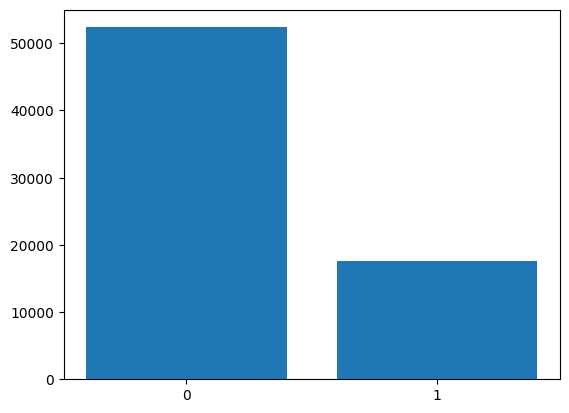

In [14]:
plt.bar(count_cholesterol.index.astype(str), count_cholesterol.values)

In [ ]:
df_cat = df.melt(
    id_vars=["cardio"],
    value_vars=["cholesterol", "gluc", "smoke", "alco", "active", "overweight"],
)

In [ ]:
df_cat = df_cat.groupby(["cardio", "variable", "value"]).size().reset_index()
# the function size() and value_counts() is the same

In [ ]:
df_cat.rename(columns={0: "total"}, inplace=True)

In [24]:
df_cat

,cardio,variable,value,total
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


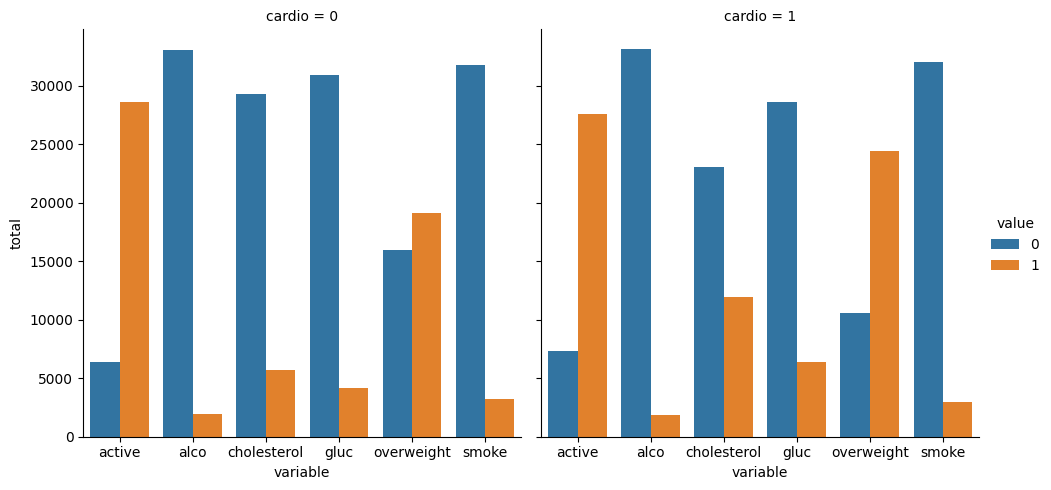

In [ ]:
graph = sns.catplot(
    data=df_cat, kind="bar", x="variable", y="total", hue="value", col="cardio"
)

In [ ]:
df_heat = df[
    (df["ap_lo"] <= df["ap_hi"])
    & (df["height"] >= df["height"].quantile(0.025))
    & (df["height"] <= df["height"].quantile(0.975))
    & (df["weight"] >= df["weight"].quantile(0.025))
    & (df["weight"] <= df["weight"].quantile(0.975))
]

In [34]:
df_heat

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70.0,130,90,0,0,0,0,1,1,0
69994,99992,21074,1,165,80.0,150,80,0,0,0,0,1,1,1
69995,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


In [37]:
corr = df_heat.corr()

In [43]:
mask = np.triu(np.ones_like(corr, dtype=int))

In [57]:
mask

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

<Axes: >

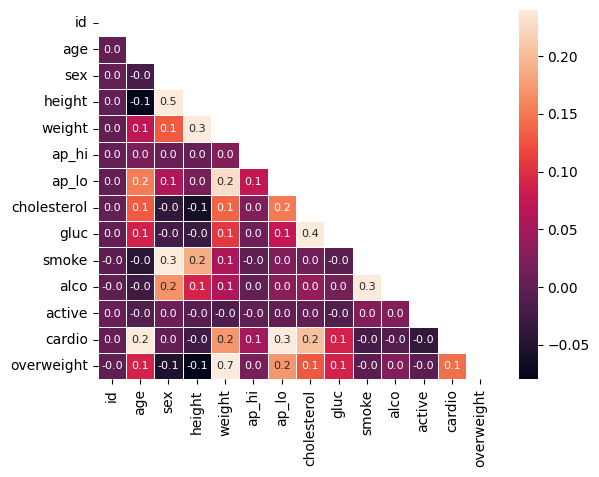

In [ ]:
sns.heatmap(
    corr,
    mask=mask,
    linewidths=0.5,
    cmap="rocket",
    vmin=-0.08,
    vmax=0.24,
    annot=True,
    fmt="0.1f",
    annot_kws={"fontsize": 8},
)

<Axes: >

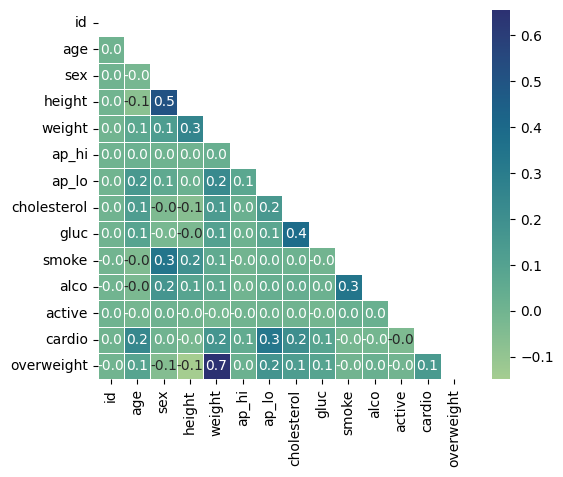

In [ ]:
sns.heatmap(
    corr, mask=mask, cmap="crest", linewidths=0.5, annot=True, square=True, fmt="0.1f"
)